# Validation score analysis

## Setup

In [7]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

# Support execution from either the notebook directory or the repository root.
experiment_dir = Path.cwd()
if not (experiment_dir / "validation_score_analysis.ipynb").exists():
    experiment_dir = experiment_dir / "experiments" / "2_determine_query_batch_size"
runs_dir = experiment_dir / "runs"
history_paths = sorted(runs_dir.glob("*/history.json"))

# Older invocations wrote run directories directly into the experiment directory.
if not history_paths:
    history_paths = sorted(experiment_dir.glob("*/history.json"))

records = []
skipped_runs = []
for history_path in history_paths:
    run_dir = history_path.parent
    try:
        with (run_dir / "config.json").open() as file:
            config = json.load(file)
        with history_path.open() as file:
            history = json.load(file)
        if not history:
            raise ValueError("history is empty")

        strategy = config.get("query_strategy", "unknown").lower().replace("_", " ").title()
        pooling = config.get("query_score_pooling", "unknown").lower()
        query_batch_size = float(config["query_batch_size"])
        seed = int(config["seed"])
        # The run name and seed identify repetitions, not experimental configurations.
        config_key = json.dumps(
            {key: value for key, value in config.items() if key not in {"name", "seed"}},
            sort_keys=True,
        )
        label = f"{query_batch_size:g}% query batch"
        run_records = []
        for row in history:
            round_number = int(row["round"])
            labeled_train_path = run_dir / f"round_{round_number:03d}" / "labeled_train.json"
            with labeled_train_path.open() as file:
                labeled_clips = json.load(file)
            labeled_events = sum(len(clip.get("events", [])) for clip in labeled_clips)

            run_records.append({
                "run": run_dir.name,
                "config_key": config_key,
                "label": label,
                "strategy": strategy,
                "pooling": pooling,
                "query_batch_size": query_batch_size,
                "seed": seed,
                "round": round_number,
                "labeled_budget_pct": float(row["labeled_budget_percent"]),
                "labeled_clips": int(row["labeled_pool_size"]),
                "labeled_events": labeled_events,
                "val_edit": float(row["val_edit"]),
                "val_f1_event": float(row["val_f1_event"]),
                "val_f1_element": float(row["val_f1_element"]),
            })
        records.extend(run_records)
    except (OSError, ValueError, TypeError, KeyError, json.JSONDecodeError) as error:
        skipped_runs.append((run_dir.name, str(error)))

seed_results_df = pd.DataFrame.from_records(records)
if seed_results_df.empty:
    raise FileNotFoundError(f"No completed run histories found under {runs_dir.resolve()}")
seed_results_df = seed_results_df.sort_values(
    ["query_batch_size", "seed", "round"]
).reset_index(drop=True)

# Combine repeated seeds for the same configuration and acquisition round.
results_df = (
    seed_results_df.groupby(
        ["config_key", "label", "strategy", "pooling", "query_batch_size", "round"],
        as_index=False,
    )
    .agg(
        seed_count=("seed", "nunique"),
        labeled_budget_pct=("labeled_budget_pct", "mean"),
        labeled_clips=("labeled_clips", "mean"),
        labeled_events=("labeled_events", "mean"),
        val_edit=("val_edit", "mean"),
        val_edit_std=("val_edit", "std"),
        val_f1_event=("val_f1_event", "mean"),
        val_f1_event_std=("val_f1_event", "std"),
        val_f1_element=("val_f1_element", "mean"),
        val_f1_element_std=("val_f1_element", "std"),
    )
    .sort_values(["query_batch_size", "round"])
    .reset_index(drop=True)
)
for metric in ("val_edit", "val_f1_event", "val_f1_element"):
    results_df[f"{metric}_std"] = results_df[f"{metric}_std"].fillna(0.0)

metric_config = {
    "val_edit": ("Validation edit score", "Edit score", None),
    "val_f1_event": ("Validation event F1", "F1 score", None),
    "val_f1_element": ("Validation element F1", "F1 score", None),
}

def plot_validation_metrics(x_column):
    """Plot seed-averaged validation metrics against a labeling-budget measure."""
    x_labels = {
        "labeled_budget_pct": "Labeled training frames (% of dataset)",
        "labeled_clips": "Number of labeled clips",
        "labeled_events": "Number of labeled events",
    }
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    for ax, (metric, (title, ylabel, limits)) in zip(axes, metric_config.items()):
        for _, config_data in results_df.groupby("config_key", sort=True):
            config_data = config_data.sort_values(x_column)
            line = ax.plot(
                config_data[x_column],
                config_data[metric],
                marker="o",
                markersize=4,
                linewidth=2,
                label=config_data["label"].iloc[0],
            )[0]
            ax.fill_between(
                config_data[x_column],
                config_data[metric] - config_data[f"{metric}_std"],
                config_data[metric] + config_data[f"{metric}_std"],
                color=line.get_color(),
                alpha=0.15,
                linewidth=0,
            )
        ax.set(title=title, xlabel=x_labels[x_column], ylabel=ylabel, ylim=limits)
        ax.ticklabel_format(axis="x", style="plain", useOffset=False)
        ax.grid(alpha=0.25)
    axes[0].legend(title="Configuration (mean ± SD)", fontsize=8)
    fig.tight_layout()
    plt.show()
    return fig, axes

source_dir = history_paths[0].parent.parent
print(
    f"Loaded {seed_results_df['run'].nunique()} completed run(s) and "
    f"combined them into {results_df['config_key'].nunique()} configuration(s) "
    f"across {len(results_df)} configuration-rounds from {source_dir.resolve()}"
)
if skipped_runs:
    print(f"Skipped {len(skipped_runs)} incomplete or malformed run(s):")
    for run, reason in skipped_runs:
        print(f"  {run}: {reason}")

Loaded 6 completed run(s) and combined them into 3 configuration(s) across 36 configuration-rounds from /mnt/ssd2/zachary/alpes/experiments/2_determine_query_batch_size/runs


## Performance vs. Annotation Budget (% of dataset)

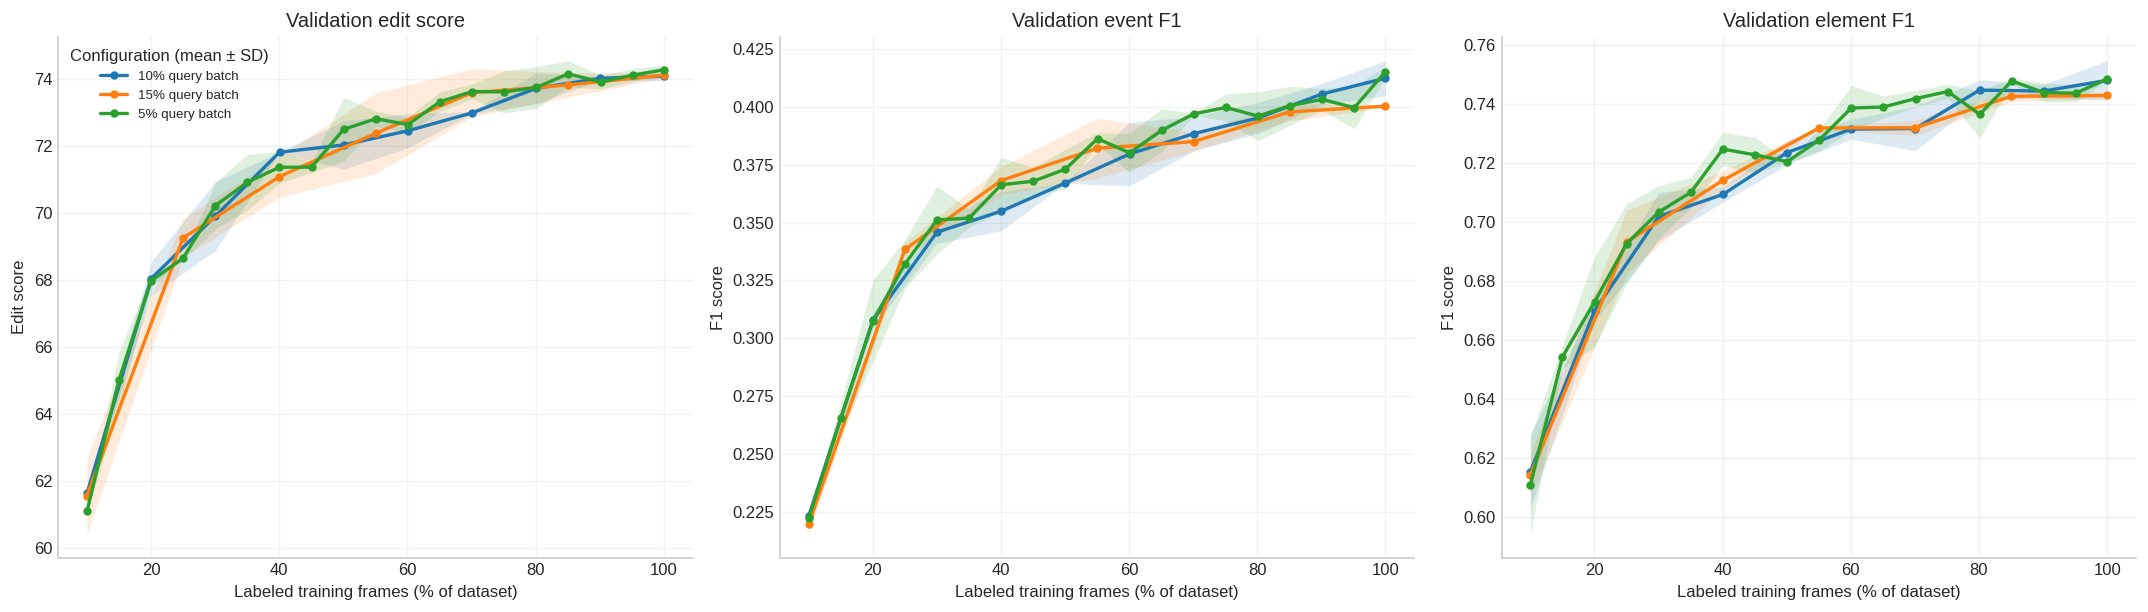

In [8]:
plot_validation_metrics("labeled_budget_pct");

## Performance vs. Number of Labeled Events

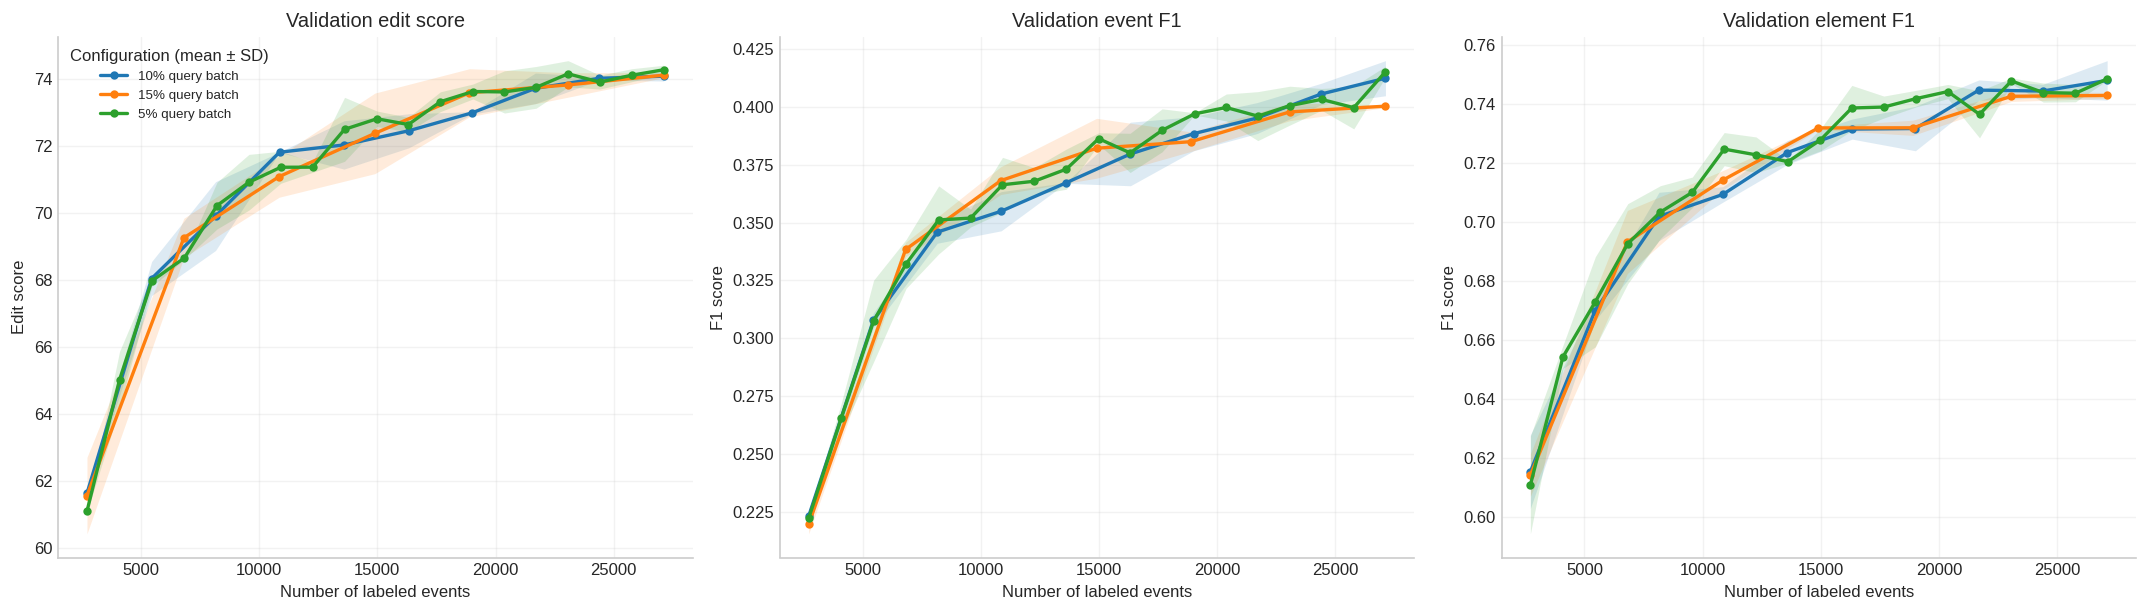

In [9]:
plot_validation_metrics("labeled_events");

## Performance vs. Acquisition Unit (No. of clips)

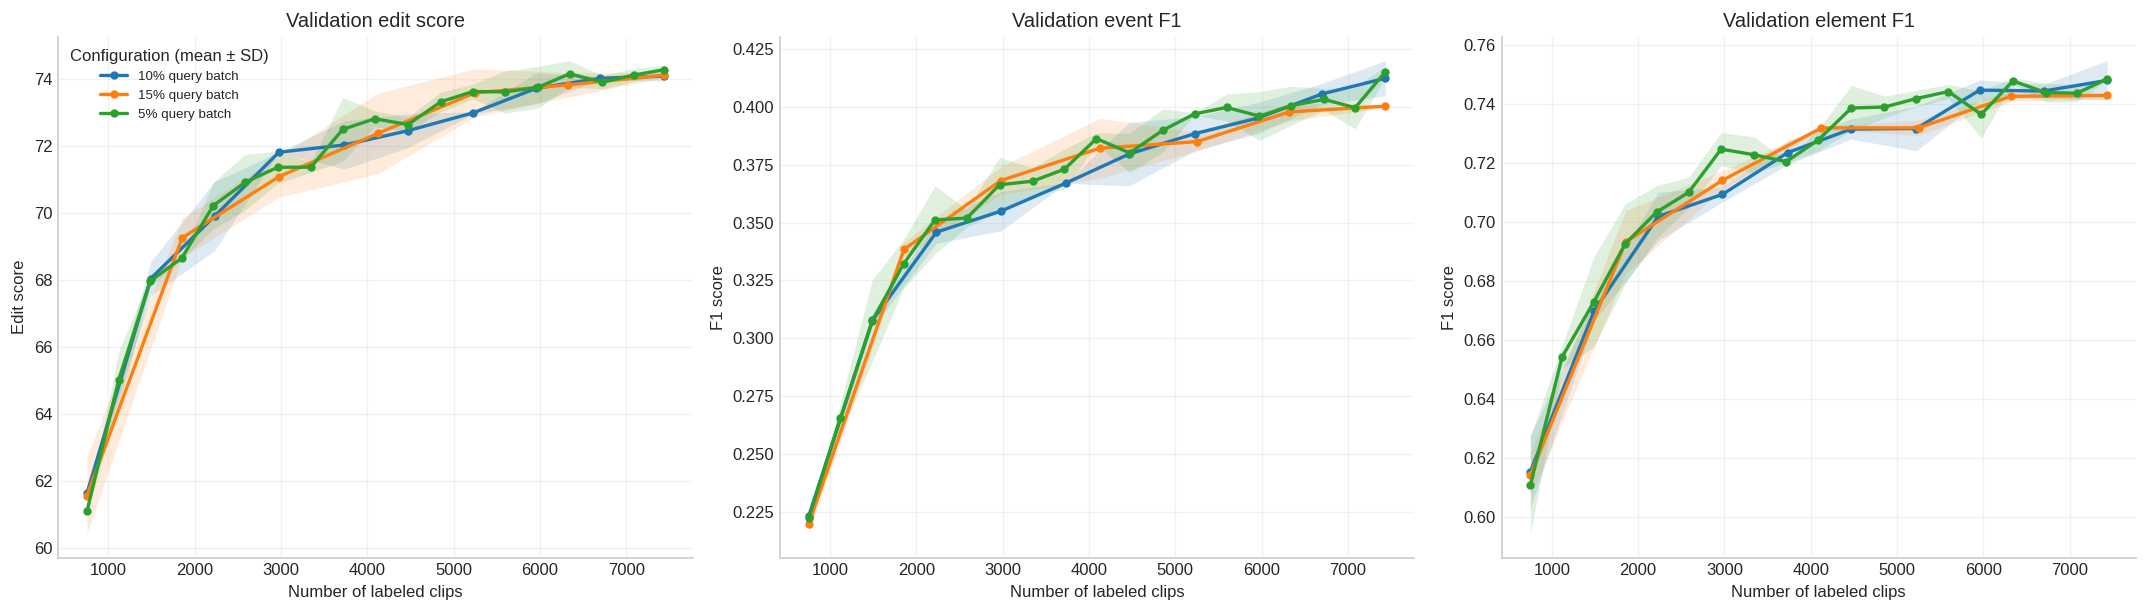

In [10]:
plot_validation_metrics("labeled_clips");